In [2]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [3]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Folder dataset:", DATASET_DIR.resolve())

Folder dataset: D:\Project-PCD-Kelompok-16\dataset


In [4]:
data = []
labels = []
file_name = []

for class_folder in sorted(DATASET_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    label = class_folder.name
    image_files = [
        file for file in sorted(class_folder.iterdir())
        if file.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"{label}: {len(image_files)} gambar")

    for image_path in image_files:
        image = cv.imread(str(image_path))

        if image is None:
            print("Gagal membaca gambar:", image_path)
            continue

        data.append(image.astype(np.uint8))
        labels.append(label)
        file_name.append(image_path.name)

data = np.array(data, dtype=object)
labels = np.array(labels)
file_name = np.array(file_name)

print("\nTotal data:", len(data))
print(pd.Series(labels).value_counts())

catterpillar: 70 gambar
snail: 70 gambar

Total data: 140
catterpillar    70
snail           70
Name: count, dtype: int64


## Data Augmentation

### Define Augmentation Function


In [ ]:
# Percobaan ini tidak memakai augmentation agar fokus pada preprocessing grayscale + resize + median + sobel.
def augment_image(image):
    return []

In [6]:
USE_AUGMENTATION = False

data_used = list(data)
labels_used = list(labels)
file_name_used = list(file_name)

if USE_AUGMENTATION:
    for image, label, filename in zip(data, labels, file_name):
        for index, augmented_image in enumerate(augment_image(image), start=1):
            data_used.append(augmented_image.astype(np.uint8))
            labels_used.append(label)
            name, ext = os.path.splitext(filename)
            file_name_used.append(f"{name}_aug{index}{ext}")

data_used = np.array(data_used, dtype=object)
labels_used = np.array(labels_used)
file_name_used = np.array(file_name_used)

print("Data sebelum augmentasi:", len(data))
print("Data yang digunakan:", len(data_used))

Data sebelum augmentasi: 140
Data yang digunakan: 140


## Data Preparation



### Define Preprocessing Function

In [7]:
TARGET_SIZE = (384, 256)


def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)


def filter(img, size, mode):

    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode="edge")

    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        case "median":
            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    canvas[i, j] = np.median(region)

    return canvas


def sobel(img):

    # Kernel Sobel
    gx_kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    gy_kernel = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])

    height, width = img.shape

    padded = np.pad(img, 1, mode='edge')

    gx = np.zeros_like(img, dtype=np.float32)
    gy = np.zeros_like(img, dtype=np.float32)

    # Konvolusi Sobel
    for i in range(height):
        for j in range(width):

            region = padded[i:i+3, j:j+3]

            gx[i, j] = np.sum(region * gx_kernel)
            gy[i, j] = np.sum(region * gy_kernel)

    # Magnitude gradient
    sobel_result = np.sqrt(gx**2 + gy**2)

    # Normalisasi ke 0-255
    sobel_result = np.clip(sobel_result, 0, 255)

    return sobel_result.astype(np.uint8)


def prepo4(image):

    # Resize + Grayscale
    gray = resize_grayscale(image)

    # Median Filter
    median = filter(gray, 3, "median")

    # Sobel
    sobel_img = sobel(median)

    return sobel_img

### Preprocessing

In [8]:
dataPreprocessed = []

for image in data_used:
    dataPreprocessed.append(prepo4(image))

dataPreprocessed = np.stack(dataPreprocessed).astype(np.uint8)

print("Jumlah data setelah preprocessing:", len(dataPreprocessed))
print("Ukuran target (width, height):", TARGET_SIZE)
print("Shape contoh gambar:", dataPreprocessed[0].shape)
print("Tipe data gambar:", dataPreprocessed.dtype)

Jumlah data setelah preprocessing: 140
Ukuran target (width, height): (384, 256)
Shape contoh gambar: (256, 384)
Tipe data gambar: uint8


### Menampilkan Gambar Dataset

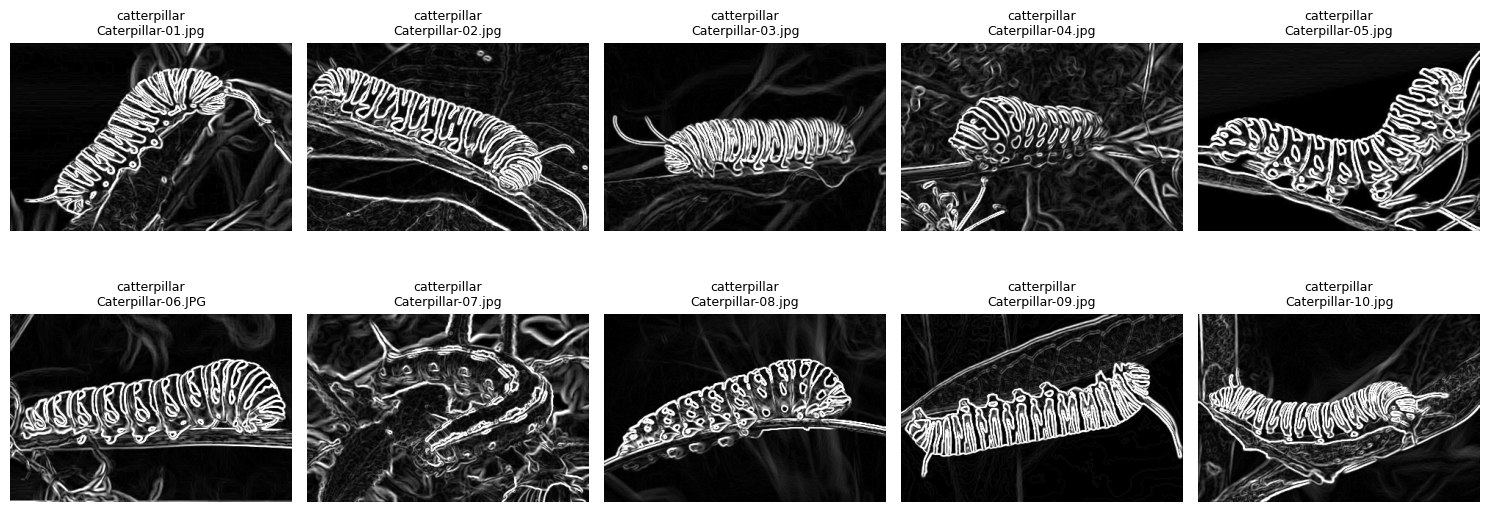

In [9]:
# Menampilkan 10 contoh gambar setelah preprocessing grayscale + resize + median + sobel
jumlah_gambar = min(10, len(dataPreprocessed))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.axis("off")

    if i < jumlah_gambar:
        ax.imshow(dataPreprocessed[i], cmap="gray")
        ax.set_title(f"{labels_used[i]}\n{file_name_used[i]}", fontsize=9)

plt.tight_layout()
plt.show()

### Feature Extraction

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Derajat harus salah satu dari: 0, 45, 90, 135.")

    return graycomatrix(
        image,
        distances=[1],
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True,
    )


In [11]:
def safe_value(value):
    value = float(value)
    if np.isnan(value) or np.isinf(value):
        return 0.0
    return value

In [12]:
def correlation(matriks):
    return safe_value(graycoprops(matriks, "correlation")[0, 0])


def dissimilarity(matriks):
    return safe_value(graycoprops(matriks, "dissimilarity")[0, 0])


def homogenity(matriks):
    return safe_value(graycoprops(matriks, "homogeneity")[0, 0])


def contrast(matriks):
    return safe_value(graycoprops(matriks, "contrast")[0, 0])


def ASM(matriks):
    return safe_value(graycoprops(matriks, "ASM")[0, 0])


def energy(matriks):
    return safe_value(graycoprops(matriks, "energy")[0, 0])


def entropyGlcm(matriks):
    return safe_value(entropy(matriks.ravel()))

In [14]:
def extract_glcm_features(image):
    if image.ndim == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    image = image.astype(np.uint8)
    features = {}

    for derajat in [0, 45, 90, 135]:
        matriks = glcm(image, derajat)
        features[f"Contrast{derajat}"] = contrast(matriks)
        features[f"Homogeneity{derajat}"] = homogenity(matriks)
        features[f"Dissimilarity{derajat}"] = dissimilarity(matriks)
        features[f"Entropy{derajat}"] = entropyGlcm(matriks)
        features[f"ASM{derajat}"] = ASM(matriks)
        features[f"Energy{derajat}"] = energy(matriks)
        features[f"Correlation{derajat}"] = correlation(matriks)
    return features


In [15]:
rows = []

for image, label, filename in zip(dataPreprocessed, labels_used, file_name_used):
    row = {
        "Filename": filename,
        "Label": label,
    }
    row.update(extract_glcm_features(image))
    rows.append(row)

hasilEkstrak = pd.DataFrame(rows)
hasilEkstrak.head()

,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,1066.902262,0.397043,13.524672,6.922084,0.021304,0.145958,0.895768,1737.764982,...,0.013981,0.118242,0.851891,2120.500323,0.288705,19.759668,7.267407,0.011790,0.108582,0.793384
1,Caterpillar-02.jpg,catterpillar,1483.471483,0.218353,17.417081,7.948402,0.003958,0.062916,0.871494,2599.394932,...,0.003640,0.060334,0.847836,2577.112302,0.161025,26.135780,8.266482,0.002736,0.052310,0.777301
2,Caterpillar-03.jpg,catterpillar,1292.264065,0.368846,12.977001,6.682855,0.012486,0.111742,0.847902,1344.923575,...,0.012823,0.113237,0.916369,1927.531501,0.299656,17.272718,6.944300,0.009019,0.094970,0.773797
3,Caterpillar-04.jpg,catterpillar,1016.459663,0.162847,15.309022,8.368370,0.000940,0.030660,0.852913,1637.737839,...,0.000868,0.029465,0.844784,1790.076517,0.121039,21.727999,8.658219,0.000609,0.024687,0.741465
4,Caterpillar-05.jpg,catterpillar,1428.670824,0.499257,15.866341,6.297803,0.061730,0.248456,0.903108,2672.748774,...,0.058226,0.241301,0.857960,3246.792577,0.389666,26.569651,6.714786,0.055414,0.235402,0.780257


### Hasil Ekstraksi Fitur

In [16]:
print("Jumlah data hasil ekstraksi:", len(hasilEkstrak))
hasilEkstrak

Jumlah data hasil ekstraksi: 140


,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,1066.902262,0.397043,13.524672,6.922084,0.021304,0.145958,0.895768,1737.764982,...,0.013981,0.118242,0.851891,2120.500323,0.288705,19.759668,7.267407,0.011790,0.108582,0.793384
1,Caterpillar-02.jpg,catterpillar,1483.471483,0.218353,17.417081,7.948402,0.003958,0.062916,0.871494,2599.394932,...,0.003640,0.060334,0.847836,2577.112302,0.161025,26.135780,8.266482,0.002736,0.052310,0.777301
2,Caterpillar-03.jpg,catterpillar,1292.264065,0.368846,12.977001,6.682855,0.012486,0.111742,0.847902,1344.923575,...,0.012823,0.113237,0.916369,1927.531501,0.299656,17.272718,6.944300,0.009019,0.094970,0.773797
3,Caterpillar-04.jpg,catterpillar,1016.459663,0.162847,15.309022,8.368370,0.000940,0.030660,0.852913,1637.737839,...,0.000868,0.029465,0.844784,1790.076517,0.121039,21.727999,8.658219,0.000609,0.024687,0.741465
4,Caterpillar-05.jpg,catterpillar,1428.670824,0.499257,15.866341,6.297803,0.061730,0.248456,0.903108,2672.748774,...,0.058226,0.241301,0.857960,3246.792577,0.389666,26.569651,6.714786,0.055414,0.235402,0.780257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,snail (95).jpg,snail,882.553851,0.097247,19.688500,9.376051,0.000349,0.018691,0.874004,1957.090657,...,0.000233,0.015258,0.778800,2137.647714,0.063703,31.230226,9.702643,0.000182,0.013499,0.694868
136,snail (96).jpg,snail,585.517165,0.235630,11.815448,8.230153,0.001395,0.037348,0.898603,1404.222209,...,0.000739,0.027179,0.809583,1456.161460,0.130341,21.333753,8.801079,0.000662,0.025720,0.748163
137,snail (97).jpg,snail,536.495808,0.303317,10.712172,7.426839,0.015510,0.124537,0.880261,907.838356,...,0.014926,0.122173,0.893672,779.627523,0.265609,13.107295,7.624357,0.014175,0.119057,0.826381
138,snail (98).jpg,snail,248.731601,0.126576,10.244554,8.000816,0.000672,0.025930,0.870066,552.164808,...,0.000631,0.025124,0.771521,622.814417,0.097085,15.059561,8.242980,0.000523,0.022862,0.675427


### Features Selection

seleksi fitur menggunakan correlation

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 12
Fitur yang digunakan:
['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Energy0', 'Correlation0', 'Contrast45', 'Dissimilarity45', 'Correlation45', 'Correlation90', 'Contrast135', 'Correlation135']


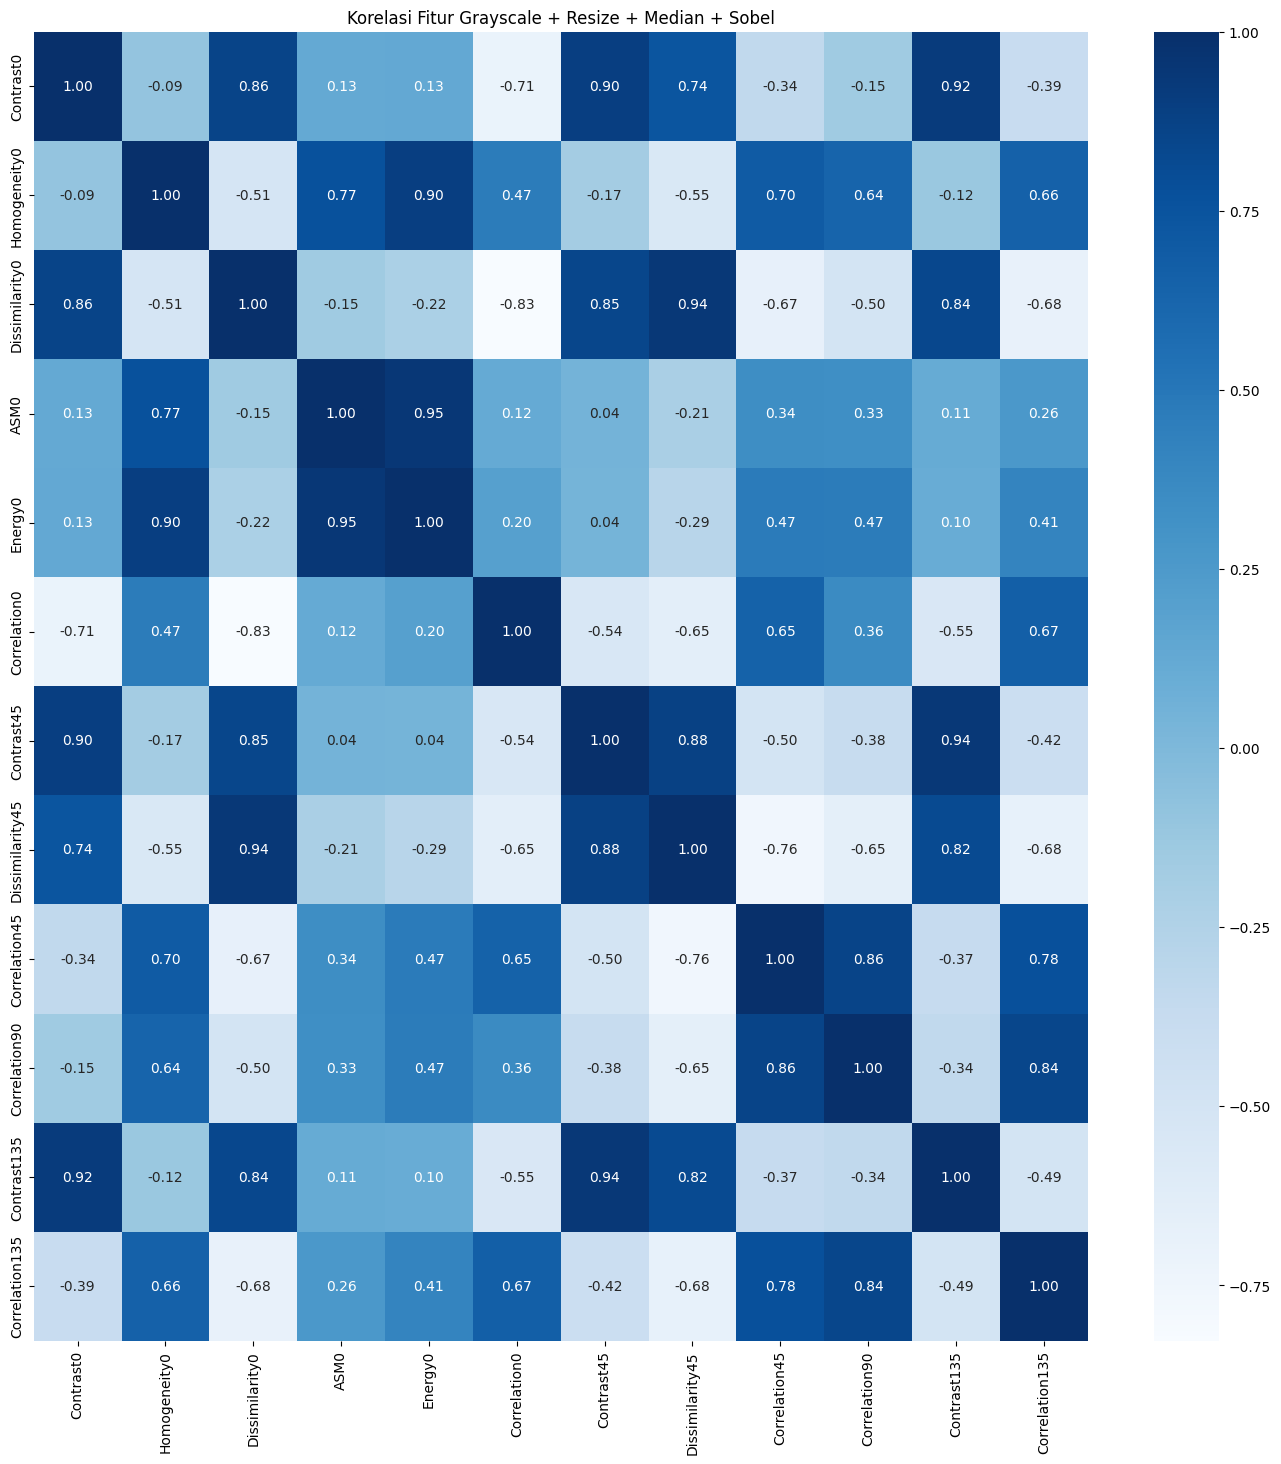

In [18]:
# Menghitung korelasi antar fitur numerik
feature_data = hasilEkstrak.drop(columns=["Label", "Filename"])
feature_data = feature_data.select_dtypes(include=[np.number])

correlation_matrix = feature_data.corr().abs()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = feature_data.columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak["Label"]

print("Jumlah fitur awal:", feature_data.shape[1])
print("Jumlah fitur setelah selection:", len(select))
print("Fitur yang digunakan:")
print(list(select))

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Grayscale + Resize + Median + Sobel")
plt.show()

## Splitting Data

In [19]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=45,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:")
print(y_train.value_counts())
print("y_test:")
print(y_test.value_counts())


X_train: (112, 12)
X_test: (28, 12)
y_train:
Label
snail           56
catterpillar    56
Name: count, dtype: int64
y_test:
Label
catterpillar    14
snail           14
Name: count, dtype: int64


## Feature Normalization


metode normalisasi menggunakan Standardization (Z-score)

In [20]:
# normalisasi mean std
std_train = X_train.std().replace(0, 1)
X_test = (X_test - X_train.mean()) / std_train
X_train = (X_train - X_train.mean()) / std_train

X_train.head()

,Contrast0,Homogeneity0,Dissimilarity0,ASM0,Energy0,Correlation0,Contrast45,Dissimilarity45,Correlation45,Correlation90,Contrast135,Correlation135
83,-0.682349,-0.495416,-0.534851,-0.482834,-0.632901,0.774403,-0.518236,-0.279049,0.052208,-0.495305,-0.554574,0.088724
95,-0.798945,0.735171,-1.137630,-0.251830,-0.015330,0.981829,-1.087124,-1.308175,1.554772,1.772824,-1.154599,1.762728
45,0.250713,-1.043518,0.753231,-0.498848,-0.711877,-0.270225,0.224823,0.597350,-0.035411,-0.902211,0.933861,-1.395871
116,-1.048011,0.004075,-1.201598,-0.429163,-0.434784,1.057682,-1.239296,-1.225419,0.799757,0.793057,-1.330743,1.133338
91,-0.326862,1.360426,-0.625062,1.945385,2.090021,0.321606,-0.557646,-0.750490,0.850192,0.762728,-0.373982,0.411560


## Modeling



### Define Model

In [21]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel="rbf", random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

hasil_model = []

### Train Random Forest Classifier

In [22]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)

print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test),
    "Precision": precision_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.96      0.96      0.96        56
       snail       0.96      0.96      0.96        56

    accuracy                           0.96       112
   macro avg       0.96      0.96      0.96       112
weighted avg       0.96      0.96      0.96       112

[[54  2]
 [ 2 54]]
Accuracy: 0.9642857142857143

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.76      0.93      0.84        14
       snail       0.91      0.71      0.80        14

    accuracy                           0.82        28
   macro avg       0.84      0.82      0.82        28
weighted avg       0.84      0.82      0.82        28

[[13  1]
 [ 4 10]]
Accuracy: 0.8214285714285714


### Train SVM Classifier

In [23]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)

print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "SVM",
    "Train Accuracy": accuracy_score(y_train, y_pred_svm_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_svm_test),
    "Precision": precision_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.88      0.66      0.76        56
       snail       0.73      0.91      0.81        56

    accuracy                           0.79       112
   macro avg       0.80      0.79      0.78       112
weighted avg       0.80      0.79      0.78       112

[[37 19]
 [ 5 51]]
Accuracy: 0.7857142857142857

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.85      0.79      0.81        14
       snail       0.80      0.86      0.83        14

    accuracy                           0.82        28
   macro avg       0.82      0.82      0.82        28
weighted avg       0.82      0.82      0.82        28

[[11  3]
 [ 2 12]]
Accuracy: 0.8214285714285714


### Train KNN Classifier

In [24]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)

print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "KNN",
    "Train Accuracy": accuracy_score(y_train, y_pred_knn_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_knn_test),
    "Precision": precision_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
})

df_hasil_model = pd.DataFrame(hasil_model)
print("Ringkasan hasil klasifikasi:")
df_hasil_model

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.87      0.73      0.80        56
       snail       0.77      0.89      0.83        56

    accuracy                           0.81       112
   macro avg       0.82      0.81      0.81       112
weighted avg       0.82      0.81      0.81       112

[[41 15]
 [ 6 50]]
Accuracy: 0.8125

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.75      0.86      0.80        14
       snail       0.83      0.71      0.77        14

    accuracy                           0.79        28
   macro avg       0.79      0.79      0.78        28
weighted avg       0.79      0.79      0.78        28

[[12  2]
 [ 4 10]]
Accuracy: 0.7857142857142857
Ringkasan hasil klasifikasi:


,Percobaan,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,grayscale_resize_median_equ,Random Forest,0.964286,0.821429,0.836898,0.821429,0.819355
1,grayscale_resize_median_equ,SVM,0.785714,0.821429,0.823077,0.821429,0.821201
2,grayscale_resize_median_equ,KNN,0.812500,0.785714,0.791667,0.785714,0.784615


## Evaluation With Confusion Matrix

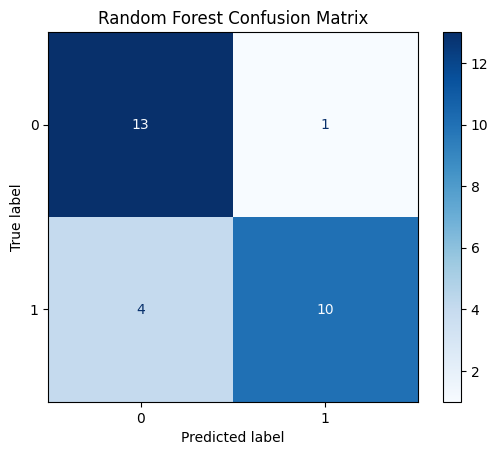

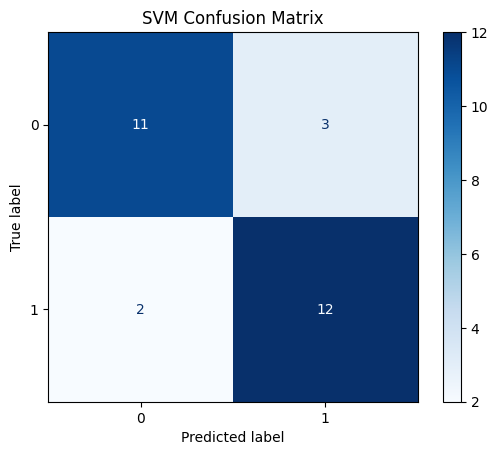

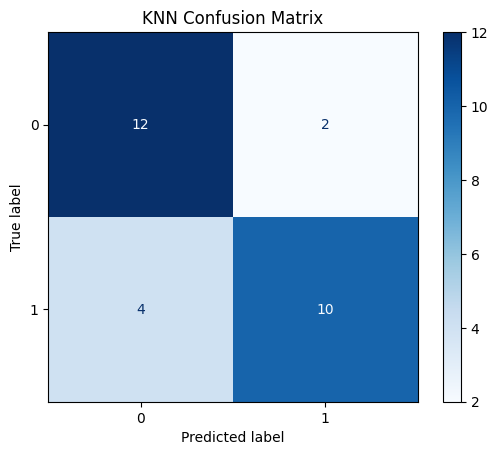

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix")